In [73]:
import math
import pulp

In [74]:
# Sets
R = [
    "Germany", "France", "Italy", "Spain", "Poland",
    "Netherlands", "Belgium", "Switzerland",
    "Austria", "Czech Republic"
]               # list of region IDs
population = {
    "Germany": 84.4,
    "France": 65.5,
    "Italy": 58.9,
    "Spain": 48.6,
    "Poland": 37.6,
    "Netherlands": 17.8,
    "Belgium": 11.8,
    "Switzerland": 8.9,
    "Austria": 9.1,
    "Czech Republic": 10.9
}
T = [
    ("Germany", "France"),
    ("Germany", "Poland"),
    ("Germany", "Netherlands"),
    ("Germany", "Belgium"),
    ("Germany", "Switzerland"),
    ("Germany", "Austria"),
    ("Germany", "Czech Republic"),

    ("France", "Spain"),
    ("France", "Belgium"),
    ("France", "Switzerland"),
    ("France", "Italy"),

    ("Italy", "Switzerland"),
    ("Italy", "Austria"),

    ("Austria", "Czech Republic"),
    ("Poland", "Czech Republic")
]               # list of (r, r2) adjacency tuples
H = [
    ("France", "Germany"),
    ("Spain", "France"),
    ("Belgium", "Germany"),
    ("Netherlands", "Germany"),
    ("Germany", "Poland"),
    ("Germany", "Czech Republic")
]               # list of (r, r2) horizontal constraints
V = [
    ("Italy", "Germany"),
    ("Switzerland", "Germany"),
    ("Austria", "Germany"),
    ("Spain", "France"),
    ("France", "Belgium"),
    ("France", "Netherlands")
]               # list of (r, r2) vertical constraints

x_init = {   # longitude
    "Germany": 10.45,
    "France": 2.21,
    "Italy": 12.57,
    "Spain": -3.75,
    "Poland": 19.15,
    "Netherlands": 5.29,
    "Belgium": 4.47,
    "Switzerland": 8.23,
    "Austria": 14.55,
    "Czech Republic": 15.47
}

y_init = {   # latitude
    "Germany": 51.17,
    "France": 46.23,
    "Italy": 41.87,
    "Spain": 40.46,
    "Poland": 51.92,
    "Netherlands": 52.13,
    "Belgium": 50.50,
    "Switzerland": 46.82,
    "Austria": 47.52,
    "Czech Republic": 49.82
}

# Parameters (dicts)
epsilon = 0.2
w = {r: math.sqrt(population[r]) for r in R}               # w[r] : float

all_pairs = set(T) | set(H) | set(V)
wr = {}
for (r, r2) in all_pairs:
    wr[(r, r2)] = (w[r] + w[r2]) / 2              # wr[(r,r2)] : float
gap = {}
for (r, r2) in all_pairs:
    if (r, r2) in T or (r2, r) in T:
        gap[(r,r2)] = 0
    else:
        gap[(r,r2)] = epsilon
a = {}

for (r, r2) in H:
    dx = x_init[r2] - x_init[r]
    dy = y_init[r2] - y_init[r]

    if abs(dx) < 1e-6:
        a[(r, r2)] = 0.0   # fallback, won't be used in H ideally
    else:
        a[(r, r2)] = dy / dx              # slope[(r,r2)] : float

a_inv = {}

for (r, r2) in V:
    dx = x_init[r2] - x_init[r]
    dy = y_init[r2] - y_init[r]

    if abs(dy) < 1e-8:
        a_inv[(r,r2)] = 0.0
    else:
        a_inv[(r,r2)] = dx / dy

c = {}
for (r, r2) in T:
    c[(r, r2)] = 0.01               # weight for deviation term

# Decision variables
x = pulp.LpVariable.dicts("x", R, cat="Continuous")
y = pulp.LpVariable.dicts("y", R, cat="Continuous")

h = pulp.LpVariable.dicts("h", T, lowBound=0, cat="Continuous")
v = pulp.LpVariable.dicts("v", T, lowBound=0, cat="Continuous")
d = pulp.LpVariable.dicts("d", all_pairs, lowBound=0, cat="Continuous")

model = pulp.LpProblem("DemersCartogram", pulp.LpMinimize)


In [75]:
# Equation 7
model += (
    pulp.lpSum(h[(r,r2)] + v[(r,r2)] for (r,r2) in T)
    + pulp.lpSum(c[(r,r2)] * d[(r,r2)] for (r,r2) in T)
)

# Equation 2
for (r,r2) in H:
    model += x[r2] - x[r] >= wr[(r,r2)] + gap[(r,r2)]

# Equation 3
for (r,r2) in V:
    model += y[r2] - y[r] >= wr[(r,r2)] + gap[(r,r2)]

# Equation 8 & 9
for (r,r2) in T:
    model += h[(r,r2)] >= x[r] - x[r2] - wr[(r,r2)] + d[(r,r2)]
    model += h[(r,r2)] >= x[r2] - x[r] - wr[(r,r2)] + d[(r,r2)]

    model += v[(r,r2)] >= y[r] - y[r2] - wr[(r,r2)] + d[(r,r2)]
    model += v[(r,r2)] >= y[r2] - y[r] - wr[(r,r2)] + d[(r,r2)]

# Equtions 10 - 13
# horizontal constraints
for (r,r2) in H:
    model += d[(r,r2)] >= ( y[r] + a[(r,r2)] * (x[r2] - x[r]) ) - y[r2]
    model += d[(r,r2)] >= y[r2] - ( y[r] + a[(r,r2)] * (x[r2] - x[r]) )

# vertical constraints
# a_inv = {}
for (r,r2) in V:
    model += d[(r,r2)] >= ( x[r] + a_inv[(r,r2)] * (y[r2] - y[r]) ) - x[r2]
    model += d[(r,r2)] >= x[r2] - ( x[r] + a_inv[(r,r2)] * (y[r2] - y[r]) )

In [76]:
model.solve()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/kuenem/miniconda3/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/2a360347afe14816a6287a4ff1555710-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/2a360347afe14816a6287a4ff1555710-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 101 COLUMNS
At line 531 RHS
At line 628 BOUNDS
At line 649 ENDATA
Problem MODEL has 96 rows, 73 columns and 384 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 67 (-29) rows, 46 (-27) columns and 217 (-167) elements
Perturbing problem by 0.001% of 1.3584925 - largest nonzero change 8.5988604e-05 ( 2.8186837%) - largest zero change 0
0  Obj 0 Primal inf 53.164734 (8)
20  Obj 1.9853365
Optimal - objective value 1.9852636
After Postsolve, objective 1.9852636, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 1.985263645 - 20

1

In [77]:
for r in R:
    print(f"{r}: x = {x[r].varValue:.2f}, y = {y[r].varValue:.2f}")

Germany: x = 9.36, y = 0.00
France: x = 0.00, y = -0.75
Italy: x = 7.10, y = -8.63
Spain: x = -7.53, y = -8.28
Poland: x = 17.02, y = 0.66
Netherlands: x = 2.66, y = 6.70
Belgium: x = 3.05, y = 5.02
Switzerland: x = 3.28, y = -6.09
Austria: x = 12.45, y = -6.10
Czech Republic: x = 15.61, y = -1.68


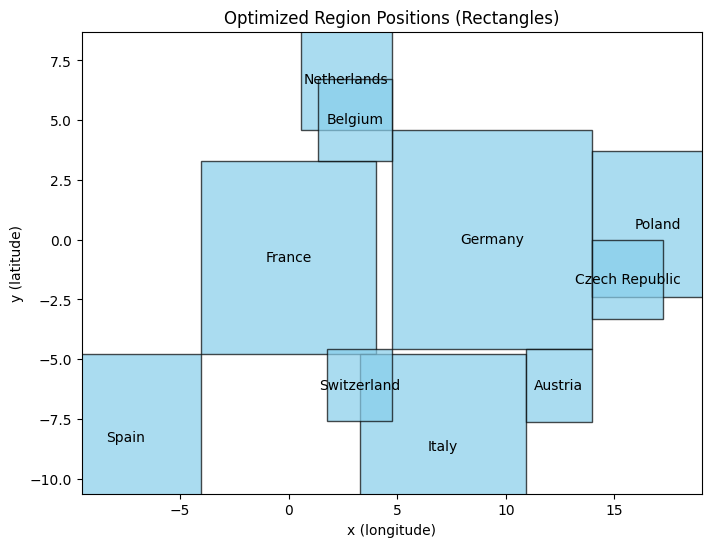

In [78]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8,6))

for r in R:
    # Example: use wr[(r, r)] as width/height, or define your own
    width = w[r]
    height = w[r]
    rect = Rectangle(
        (x[r].varValue - width/2, y[r].varValue - height/2),  # bottom left corner
        width, height,
        edgecolor='black', facecolor='skyblue', alpha=0.7
    )
    ax.add_patch(rect)
    ax.text(x[r].varValue, y[r].varValue, r, ha='center', va='center')

ax.set_xlabel("x (longitude)")
ax.set_ylabel("y (latitude)")
ax.set_title("Optimized Region Positions (Rectangles)")
ax.set_xlim(min([x[r].varValue for r in R]) - 2, max([x[r].varValue for r in R]) + 2)
ax.set_ylim(min([y[r].varValue for r in R]) - 2, max([y[r].varValue for r in R]) + 2)
plt.show()